In [1]:
import os
import time
import sys
import openmc
import re
import subprocess
from Geometry_methods import get_material_by_name
import matplotlib.pyplot as plt

mats = openmc.Materials.from_xml('materials.xml')

# Shared folder inside the container (must match the -v mount)
shared_folder = "/root/SR_Module"

# Input and output files
input_file = os.path.join(shared_folder, "SR.IN")

In [5]:
# Step 1: Write input file for SRModule
symbol_to_element_name = {
    "H": "Hydrogen", "He": "Helium", "Li": "Lithium", "Be": "Beryllium",
    "B": "Boron", "C": "Carbon", "N": "Nitrogen", "O": "Oxygen",
    "F": "Fluorine", "Ne": "Neon", "Na": "Sodium", "Mg": "Magnesium",
    "Al": "Aluminum", "Si": "Silicon", "P": "Phosphorus", "S": "Sulfur",
    "Cl": "Chlorine", "Ar": "Argon", "K": "Potassium", "Ca": "Calcium",
    "Sc": "Scandium", "Ti": "Titanium", "V": "Vanadium", "Cr": "Chromium",
    "Mn": "Manganese", "Fe": "Iron", "Co": "Cobalt", "Ni": "Nickel",
    "Cu": "Copper", "Zn": "Zinc", "Ga": "Gallium", "Ge": "Germanium",
    "As": "Arsenic", "Se": "Selenium", "Br": "Bromine", "Kr": "Krypton",
    "Rb": "Rubidium", "Sr": "Strontium", "Y": "Yttrium", "Zr": "Zirconium",
    "Nb": "Niobium", "Mo": "Molybdenum", "Tc": "Technetium", "Ru": "Ruthenium",
    "Rh": "Rhodium", "Pd": "Palladium", "Ag": "Silver", "Cd": "Cadmium",
    "In": "Indium", "Sn": "Tin", "Sb": "Antimony", "Te": "Tellurium",
    "I": "Iodine", "Xe": "Xenon", "Cs": "Cesium", "Ba": "Barium",
    "La": "Lanthanum", "Ce": "Cerium", "Pr": "Praseodymium", "Nd": "Neodymium",
    "Pm": "Promethium", "Sm": "Samarium", "Eu": "Europium", "Gd": "Gadolinium",
    "Tb": "Terbium", "Dy": "Dysprosium", "Ho": "Holmium", "Er": "Erbium",
    "Tm": "Thulium", "Yb": "Ytterbium", "Lu": "Lutetium", "Hf": "Hafnium",
    "Ta": "Tantalum", "W": "Tungsten", "Re": "Rhenium", "Os": "Osmium",
    "Ir": "Iridium", "Pt": "Platinum", "Au": "Gold", "Hg": "Mercury",
    "Tl": "Thallium", "Pb": "Lead", "Bi": "Bismuth", "Po": "Polonium",
    "At": "Astatine", "Rn": "Radon", "Fr": "Francium", "Ra": "Radium",
    "Ac": "Actinium", "Th": "Thorium", "Pa": "Protactinium", "U": "Uranium",
    "Np": "Neptunium", "Pu": "Plutonium", "Am": "Americium", "Cm": "Curium",
    "Bk": "Berkelium", "Cf": "Californium", "Es": "Einsteinium", "Fm": "Fermium",
    "Md": "Mendelevium", "No": "Nobelium", "Lr": "Lawrencium", "Rf": "Rutherfordium",
    "Db": "Dubnium", "Sg": "Seaborgium", "Bh": "Bohrium", "Hs": "Hassium",
    "Mt": "Meitnerium", "Ds": "Darmstadtium", "Rg": "Roentgenium", "Cn": "Copernicium",
    "Nh": "Nihonium", "Fl": "Flerovium", "Mc": "Moscovium", "Lv": "Livermorium",
    "Ts": "Tennessine", "Og": "Oganesson"
}
def make_SR_in (input_file,mat,E_min=10,E_max=10000,state=0):
    '''
    Method for making txt for .in files used by SR module
    Parameters
    ----------
    mat: openmc.Materiael
        The material used
    E_min: float
        minimum energy (keV)
    E_max: float
        maximum energy (keV)
    state: int
        solid=0, gas=1
    Returns
    -------
    None
    '''
    empty_string = ''
    with open(input_file, "w",newline="\n") as f:
        f.write('---Stopping/Range Input Data (Number-format: Period = Decimal Point)\r\n')
        f.write('---Output File Name\r\n')
        f.write(f'"{mat.name}"\r\n')
        f.write('---Ion(Z), Ion Mass(u)\r\n')
        f.write('2\t4\r\n')  # Helium-4 ion
        f.write('---Target Data: (Solid=0,Gas=1), Density(g/cm3), Compound Corr.\r\n')
        f.write(f'{state}\t {mat.density}\t 0\r\n')  # Note single space after first column
        f.write('---Number of Target Elements\r\n')
        f.write(f'{len(mat.nuclides)}\r\n')
        f.write('---Target Elements: (Z), Target name, Stoich, Target Mass(u)\r\n')
        
        for nuc in mat.nuclides:
            Stoich = nuc[1]
            Z, A, m = openmc.data.zam(nuc[0])
            symbol = re.match('([A-Za-z]+)', nuc[0])[0]
            element_name = symbol_to_element_name[symbol]
            # Match the working spacing exactly:
            # - 3 spaces after Z
            # - element name padded to 15 characters
            # - tab between name and stoich
            # - spaces between stoich and mass number
            f.write(f'{Z:<3}  "{symbol_to_element_name[symbol]}"  {empty_string:<8}\t {Stoich:<25}  {A}\r\n')
        
        f.write('---Output Stopping Units (1-8)\r\n')
        f.write('1\r\n')  # Units eV / Angstrom
        f.write('---Ion Energy : E-Min(keV), E-Max(keV)\r\n')
        f.write(f'{E_min}\t{E_max}')
        f.write(f'\r\n\r\n\r\n\r\n\r\n\r\n')


fuel = get_material_by_name("Fuel_C",mats)

make_SR_in(input_file,fuel)



In [3]:
# Step 2: Wait for Windows host to run SRModule.exe
print("Waiting for SRModule to produce output...")
while not os.path.exists(output_file):
    time.sleep(1)  # check every second

Waiting for SRModule to produce output...


end of file
end of file
end of file


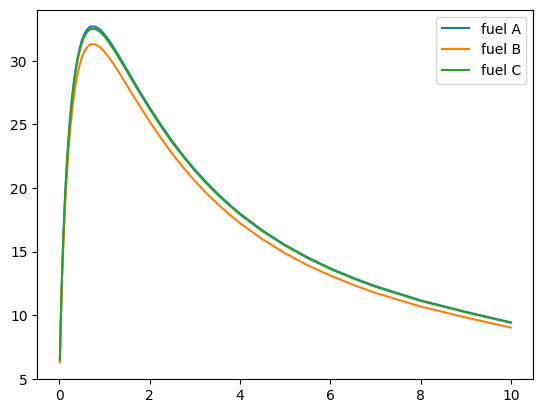

In [4]:
def read_SR_file(fuel_name,shared_folder):
    '''
    Method for reading an file made from SR module
    Parameters
    ----------
    fuel_name: str
        name of the file, which is the fuel name when using make_SR_in
    shared_folder: str
        path to the folder shared between windows and linux
    
    Returns
    -------
    energies :array[float], stopping_powers: array[float]
    '''
    
    #Import file
    output_file = os.path.join(shared_folder, fuel_name)
    
    energies = [] #in Mev
    stopping_powers = [] #in eV/Angstrom
    # Step 3: Read output
    with open(output_file, "r") as f:
        while True:
            line = f.readline()
            try:
                energy, unit, val1, val2, a1, unit1, a2, unit2, a3, unit3 = line.split()
                break
            except:
                n=0
        while n < 100:
            line = f.readline()
            #print(line)
            try:
                energy, unit, val1, val2, a1, unit1, a2, unit2, a3, unit3 = line.split()
            except:
                print('end of file')
                break
            if unit == 'keV':
                energy = float(energy.replace(",", "."))
                energies.append(energy/1000)
            elif unit=="MeV":
                energy = float(energy.replace(",", "."))
                energies.append(energy)
            else:
                print("Something went wrong in line",results)
            val1 = float(val1.replace(",", "."))
            val2 = float(val2.replace(",", "."))
            stopping_powers.append(val1+val2)
            n+=1
    return energies,stopping_powers

energies, stopping_powers = read_SR_file('fuel_A',shared_folder)
energies1, stopping_powers1 = read_SR_file('fuel_B',shared_folder)
energies2, stopping_powers2 = read_SR_file('fuel_C',shared_folder)

fig, ax = plt.subplots()

ax.plot(energies,stopping_powers,label='fuel A')
ax.plot(energies1,stopping_powers1,label='fuel B')
ax.plot(energies2,stopping_powers2,label='fuel C')

ax.legend()